# LWR PDE Solver — Demo Notebook

This notebook demonstrates the continuum PDE-based traffic flow model implemented for PX915.

The model solves the **Lighthill–Whitham–Richards (LWR)** scalar conservation law:

$$\frac{\partial \rho}{\partial t} + \frac{\partial q(\rho)}{\partial x} = 0$$

with the **Greenshields fundamental diagram** as closure:

$$q(\rho) = v_{\max} \cdot \rho \cdot \left(1 - \frac{\rho}{\rho_{\max}}\right)$$

Three demonstrations:
1. **Riemann problem — shock** (with analytical shock speed overlaid)
2. **Riemann problem — rarefaction**
3. **Greenshields fundamental diagram** from a parameter sweep

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src' / 'python'))
sys.path.insert(0, str(ROOT / 'tests'))

from pde_runner import run_pde, load_pde_netcdf, q_of_rho, rho_critical
from pde_visualisation import plot_pde_spacetime, plot_pde_snapshots, plot_pde_flow
from exact_riemann import exact_riemann_lwr

PLOTS_DIR = ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
DATA_DIR = ROOT / 'data' / 'output'
DATA_DIR.mkdir(parents=True, exist_ok=True)

V_MAX   = 1.0
RHO_MAX = 1.0
RC      = rho_critical(RHO_MAX)  # 0.5

print('Setup complete.')

Setup complete.


---
## 1. Riemann Problem — Shock

Initial condition: $\rho_L = 0.1$ (free-flow), $\rho_R = 0.7$ (congested), discontinuity at $x = 0.5$.

Since $\rho_L < \rho_R$, the entropy solution is a **shock** travelling at the Rankine–Hugoniot speed:

$$s = \frac{q(\rho_R) - q(\rho_L)}{\rho_R - \rho_L}$$

In [2]:
RHO_L_SHOCK = 0.1
RHO_R_SHOCK = 0.7
M_SHOCK     = 200
N_STEPS     = 500

shock_nc = DATA_DIR / 'demo_shock.nc'
run_pde(
    dict(M=M_SHOCK, n_steps=N_STEPS, ic_type='riemann', flux_type='godunov',
         bc_type='open', rho_left_bc=RHO_L_SHOCK, rho_right_bc=RHO_R_SHOCK),
    output_path=shock_nc,
)
shock_data = load_pde_netcdf(shock_nc)

# Rankine-Hugoniot shock speed
s_shock = (q_of_rho(RHO_R_SHOCK, V_MAX, RHO_MAX) - q_of_rho(RHO_L_SHOCK, V_MAX, RHO_MAX)) \
          / (RHO_R_SHOCK - RHO_L_SHOCK)
print(f'Rankine-Hugoniot shock speed  s = {s_shock:.4f}')
print(f'(positive = rightward, negative = leftward)')

Rankine-Hugoniot shock speed  s = 0.2000
(positive = rightward, negative = leftward)


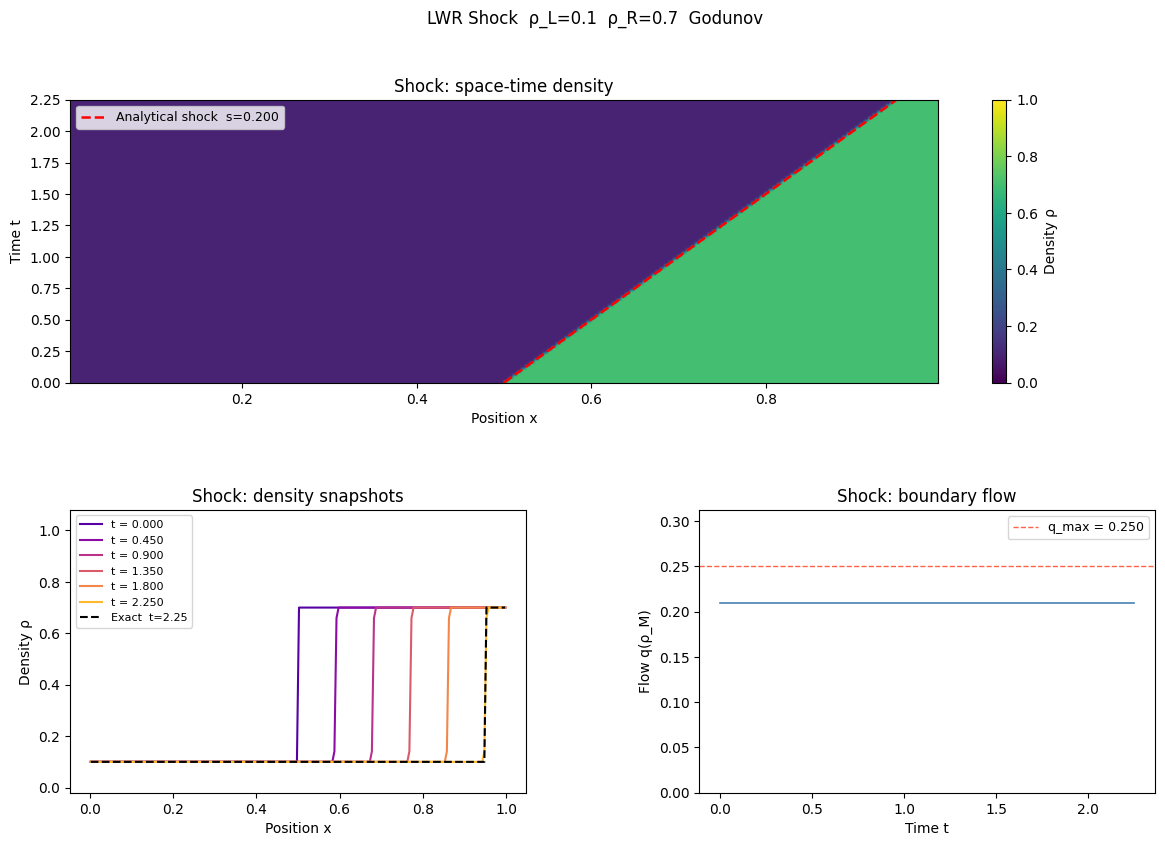

Saved to plots/demo_shock.png


In [3]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

ax_st   = fig.add_subplot(gs[0, :])
ax_snap = fig.add_subplot(gs[1, 0])
ax_flow = fig.add_subplot(gs[1, 1])

# Space-time with analytical shock trajectory overlaid
plot_pde_spacetime(shock_data, ax=ax_st, title='Shock: space-time density')
t_arr = shock_data['time']
x_shock_line = 0.5 + s_shock * t_arr
ax_st.plot(x_shock_line, t_arr, 'r--', linewidth=1.8,
           label=f'Analytical shock  s={s_shock:.3f}')
ax_st.legend(fontsize=9, loc='upper left')

# Density snapshots with exact solution at final time
plot_pde_snapshots(shock_data, ax=ax_snap, title='Shock: density snapshots')
x_arr    = shock_data['x']
t_final  = float(t_arr[-1])
rho_exact = exact_riemann_lwr(x_arr, t_final, RHO_L_SHOCK, RHO_R_SHOCK, V_MAX, RHO_MAX)
ax_snap.plot(x_arr, rho_exact, 'k--', linewidth=1.5, label=f'Exact  t={t_final:.2f}')
ax_snap.legend(fontsize=8)

plot_pde_flow(shock_data, ax=ax_flow, title='Shock: boundary flow')

fig.suptitle(f'LWR Shock  ρ_L={RHO_L_SHOCK}  ρ_R={RHO_R_SHOCK}  Godunov', fontsize=12)
fig.savefig(PLOTS_DIR / 'demo_shock.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to plots/demo_shock.png')

---
## 2. Riemann Problem — Rarefaction

Initial condition: $\rho_L = 0.8$ (congested), $\rho_R = 0.2$ (free-flow), discontinuity at $x = 0.5$.

Since $\rho_L > \rho_R$ and the fan spans the critical density $\rho_c = 0.5$, the entropy solution is a **sonic rarefaction fan**. Inside the fan the exact solution is self-similar:

$$\rho(x, t) = \frac{\rho_{\max}}{2}\left(1 - \frac{x - x_0}{v_{\max} \, t}\right)$$

In [4]:
RHO_L_RARE = 0.8
RHO_R_RARE = 0.2

rare_nc = DATA_DIR / 'demo_rarefaction.nc'
run_pde(
    dict(M=200, n_steps=N_STEPS, ic_type='riemann', flux_type='godunov',
         bc_type='open', rho_left_bc=RHO_L_RARE, rho_right_bc=RHO_R_RARE),
    output_path=rare_nc,
)
rare_data = load_pde_netcdf(rare_nc)
print('Rarefaction run complete.')

Rarefaction run complete.


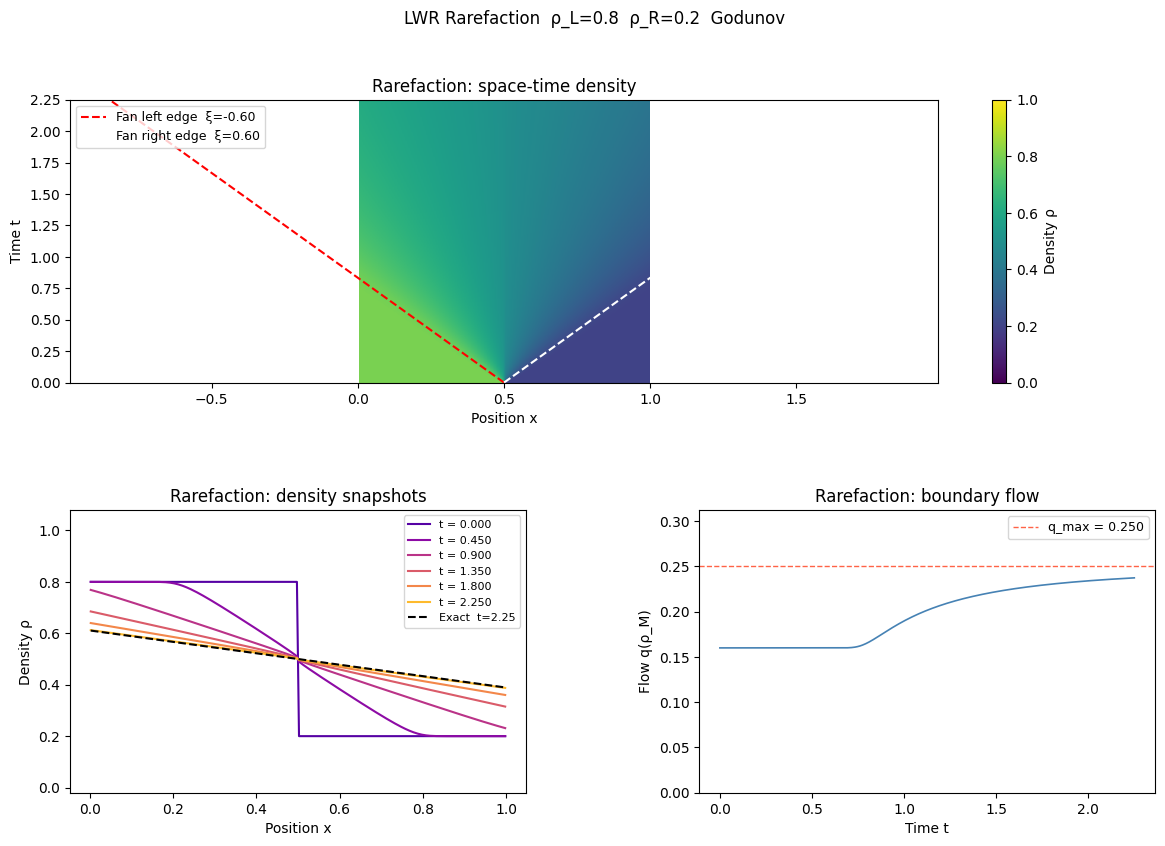

Saved to plots/demo_rarefaction.png


In [5]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

ax_st   = fig.add_subplot(gs[0, :])
ax_snap = fig.add_subplot(gs[1, 0])
ax_flow = fig.add_subplot(gs[1, 1])

# Space-time with fan edge trajectories overlaid
plot_pde_spacetime(rare_data, ax=ax_st, title='Rarefaction: space-time density')
t_arr  = rare_data['time']
from pde_runner import dq_drho
xi_L = dq_drho(RHO_L_RARE, V_MAX, RHO_MAX)  # left edge of fan (slower)
xi_R = dq_drho(RHO_R_RARE, V_MAX, RHO_MAX)  # right edge of fan (faster)
ax_st.plot(0.5 + xi_L * t_arr, t_arr, 'r--', linewidth=1.5,
           label=f'Fan left edge  ξ={xi_L:.2f}')
ax_st.plot(0.5 + xi_R * t_arr, t_arr, 'w--', linewidth=1.5,
           label=f'Fan right edge  ξ={xi_R:.2f}')
ax_st.legend(fontsize=9, loc='upper left')

# Snapshots with exact solution at final time
plot_pde_snapshots(rare_data, ax=ax_snap, title='Rarefaction: density snapshots')
x_arr    = rare_data['x']
t_final  = float(t_arr[-1])
rho_exact = exact_riemann_lwr(x_arr, t_final, RHO_L_RARE, RHO_R_RARE, V_MAX, RHO_MAX)
ax_snap.plot(x_arr, rho_exact, 'k--', linewidth=1.5, label=f'Exact  t={t_final:.2f}')
ax_snap.legend(fontsize=8)

plot_pde_flow(rare_data, ax=ax_flow, title='Rarefaction: boundary flow')

fig.suptitle(f'LWR Rarefaction  ρ_L={RHO_L_RARE}  ρ_R={RHO_R_RARE}  Godunov', fontsize=12)
fig.savefig(PLOTS_DIR / 'demo_rarefaction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to plots/demo_rarefaction.png')

---
## 3. Greenshields Fundamental Diagram

Sweep over inflow density $\rho_{\text{left}}$ from 0 to $\rho_{\max}$ and record the steady-state
right-boundary flow $q = q(\rho_M)$. This traces out the Greenshields parabola:

$$q(\rho) = v_{\max} \cdot \rho \cdot \left(1 - \frac{\rho}{\rho_{\max}}\right)$$

The maximum flow $q_{\max} = v_{\max} \rho_{\max} / 4$ occurs at the critical density $\rho_c = \rho_{\max}/2$.

In [6]:
N_SWEEP = 25
rho_in  = np.linspace(0.02, 0.98, N_SWEEP)

q_greenshields = np.empty(N_SWEEP)
q_newell       = np.empty(N_SWEEP)

for k, rho_left in enumerate(rho_in):
    # Greenshields run
    fd_g = DATA_DIR / f'fd_green_{k:03d}.nc'
    run_pde(
        dict(M=100, n_steps=800, ic_type='constant', flux_type='godunov',
             bc_type='open', rho_left_bc=float(rho_left), rho_right_bc=float(rho_left)),
        output_path=fd_g,
    )
    q_greenshields[k] = float(np.mean(load_pde_netcdf(fd_g)['flow'][-160:]))

    # Newell run
    fd_n = DATA_DIR / f'fd_newell_{k:03d}.nc'
    run_pde(
        dict(M=100, n_steps=800, ic_type='constant', flux_type='newell',
             bc_type='open', rho_left_bc=float(rho_left), rho_right_bc=float(rho_left)),
        output_path=fd_n,
    )
    q_newell[k] = float(np.mean(load_pde_netcdf(fd_n)['flow'][-160:]))

    print(f'  ρ={rho_left:.3f}  green={q_greenshields[k]:.4f}  newell={q_newell[k]:.4f}')

  ρ=0.020  green=0.0196  newell=0.0200
  ρ=0.060  green=0.0564  newell=0.0600
  ρ=0.100  green=0.0900  newell=0.1000
  ρ=0.140  green=0.1204  newell=0.1400
  ρ=0.180  green=0.1476  newell=0.1800
  ρ=0.220  green=0.1716  newell=0.2200
  ρ=0.260  green=0.1924  newell=0.2600
  ρ=0.300  green=0.2100  newell=0.3000
  ρ=0.340  green=0.2244  newell=0.3300
  ρ=0.380  green=0.2356  newell=0.3100
  ρ=0.420  green=0.2436  newell=0.2900
  ρ=0.460  green=0.2484  newell=0.2700
  ρ=0.500  green=0.2500  newell=0.2500
  ρ=0.540  green=0.2484  newell=0.2300
  ρ=0.580  green=0.2436  newell=0.2100
  ρ=0.620  green=0.2356  newell=0.1900
  ρ=0.660  green=0.2244  newell=0.1700
  ρ=0.700  green=0.2100  newell=0.1500
  ρ=0.740  green=0.1924  newell=0.1300
  ρ=0.780  green=0.1716  newell=0.1100
  ρ=0.820  green=0.1476  newell=0.0900
  ρ=0.860  green=0.1204  newell=0.0700
  ρ=0.900  green=0.0900  newell=0.0500
  ρ=0.940  green=0.0564  newell=0.0300
  ρ=0.980  green=0.0196  newell=0.0100


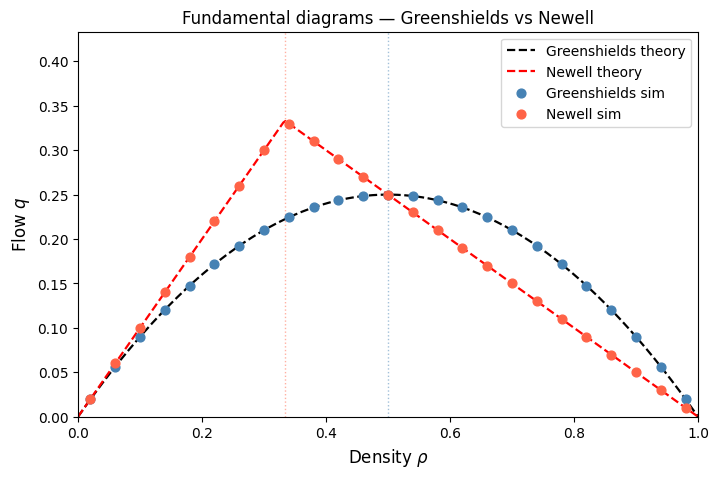

In [7]:
from pde_runner import q_newell as q_newell_func, rho_critical_newell

rho_theory = np.linspace(0.0, RHO_MAX, 300)
q_g_theory = q_of_rho(rho_theory, V_MAX, RHO_MAX)
q_n_theory = q_newell_func(rho_theory, V_MAX, RHO_MAX)

q_max_g = V_MAX * RHO_MAX / 4.0
rc_n    = rho_critical_newell(V_MAX, RHO_MAX)
q_max_n = V_MAX * rc_n

fig, ax = plt.subplots(figsize=(8, 5))

# Theoretical curves
ax.plot(rho_theory, q_g_theory, 'k--', linewidth=1.6, label='Greenshields theory')
ax.plot(rho_theory, q_n_theory, 'r--', linewidth=1.6, label='Newell theory')

# Simulation points
ax.scatter(rho_in, q_greenshields, s=40, color='steelblue', zorder=3, label='Greenshields sim')
ax.scatter(rho_in, q_newell,       s=40, color='tomato',    zorder=3, label='Newell sim')

# Critical points
ax.axvline(RC,   color='steelblue', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(rc_n, color='tomato',    linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Density $\\rho$', fontsize=12)
ax.set_ylabel('Flow $q$', fontsize=12)
ax.set_xlim(0, RHO_MAX)
ax.set_ylim(0, max(q_max_g, q_max_n) * 1.3)
ax.set_title('Fundamental diagrams — Greenshields vs Newell', fontsize=12)
ax.legend(fontsize=10)

fig.savefig(PLOTS_DIR / 'fundamental_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Demo | IC | Result |
|------|----|--------|
| Shock | $\rho_L=0.1$, $\rho_R=0.7$ | Sharp shock travelling at Rankine–Hugoniot speed |
| Rarefaction | $\rho_L=0.8$, $\rho_R=0.2$ | Smooth fan spanning critical density |
| Fundamental diagram | Constant IC sweep | Recovers Greenshields parabola from simulation |

The Godunov scheme correctly captures both shock and rarefaction structure, and the steady-state flow matches the analytical Greenshields curve.